In [14]:
import numpy as np
from numpy.random import randn
import math


class myRNN:

    def __init__(self, input_size, output_size, hidden_size):
        
        self.Wxh = randn(hidden_size, input_size) / input_size
        self.Whh = randn(hidden_size, hidden_size) / hidden_size
        self.Why = randn(output_size, hidden_size) / hidden_size

        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((output_size, 1))

    def forward(self, inputs):
        
        h = np.zeros((self.Whh.shape[0], 1))
        self.last_hs = {0: h}
        self.last_inputs = inputs

        for i, x in enumerate(inputs):
            h = np.tanh(self.Wxh @ x + self.Whh @ h + self.bh)
            self.last_hs[i + 1] = h

        y = self.Why @ h + self.by

        return y, h

    def backprop(self, d_y, learn_rate):

        n = len(self.last_inputs)

        d_Why = d_y @ self.last_hs[n].T
        d_by = d_y.copy()

        d_h = self.Why.T @ d_y

        d_Wxh = np.zeros_like(self.Wxh)
        d_Whh = np.zeros_like(self.Whh)
        d_bh = np.zeros_like(self.bh)

        for t in reversed(range(n)):

            d_raw = (1 - self.last_hs[t + 1] ** 2) * d_h

            d_Wxh += d_raw @ self.last_inputs[t].T
            d_Whh += d_raw @ self.last_hs[t].T
            d_bh += d_raw

            d_h = self.Whh.T @ d_raw

        for d in [d_Wxh, d_Whh, d_Why, d_bh, d_by]:
            np.clip(d, -1, 1, out=d)

        self.Wxh -= learn_rate * d_Wxh
        self.Whh -= learn_rate * d_Whh
        self.Why -= learn_rate * d_Why
        self.bh -= learn_rate * d_bh
        self.by -= learn_rate * d_by

## Проверка работоспособности класса myRNN

Обучим RNN по последовательности из 3 случайных чисел предсказывать их сумму, протестируем и выведем график убывания функции потерь

In [15]:
np.random.seed(42)

input_size = 1
output_size = 1
hidden_size = 16
seq_length = 3

rnn = myRNN(input_size, output_size, hidden_size)

learning_rate = 0.005
num_epochs = 500
losses = []

for epoch in range(num_epochs):

    raw = np.random.uniform(-1, 1, seq_length)
    inputs = [raw[i].reshape(input_size, 1) for i in range(seq_length)]
    target = raw.sum().reshape(output_size, 1)

    y_pred, h = rnn.forward(inputs)

    loss = ((y_pred - target) ** 2).item()
    losses.append(loss)

    d_y = 2 * (y_pred - target)

    rnn.backprop(d_y, learning_rate)

    if (epoch + 1) % 100 == 0:
        print(f"Эпоха {epoch+1:4d} -- Loss: {loss:.6f}")

print("\nОбучение завершено")

Эпоха  100 -- Loss: 0.594348
Эпоха  200 -- Loss: 0.012260
Эпоха  300 -- Loss: 0.120184
Эпоха  400 -- Loss: 0.015926
Эпоха  500 -- Loss: 0.051090

Обучение завершено


In [16]:
print("Тест на новых данных:")
print(f"{'Вход':>25s} | {'Цель (сумма)':>10s} | {'Предсказание':>10s} | {'Ошибка':>10s}")

for _ in range(5):
    raw = np.random.uniform(-1, 1, seq_length)
    inputs = [raw[i].reshape(input_size, 1) for i in range(seq_length)]
    target = raw.sum()

    y_pred, _ = rnn.forward(inputs)
    pred = y_pred.item()

    print(f"{str(np.round(raw, 3)):>25s} | {target:>12.4f} | {pred:>12.4f} | {abs(target - pred):>10.4f}")

Тест на новых данных:
                     Вход | Цель (сумма) | Предсказание |     Ошибка
   [-0.914 -0.67  -0.737] |      -2.3206 |      -1.8466 |     0.4740
   [ 0.452  0.636 -0.573] |       0.5146 |       0.5844 |     0.0698
      [0.012 0.681 0.466] |       1.1587 |       1.4166 |     0.2579
      [0.084 0.181 0.017] |       0.2819 |       0.5159 |     0.2340
   [-0.405  0.13   0.378] |       0.1029 |       0.0713 |     0.0316


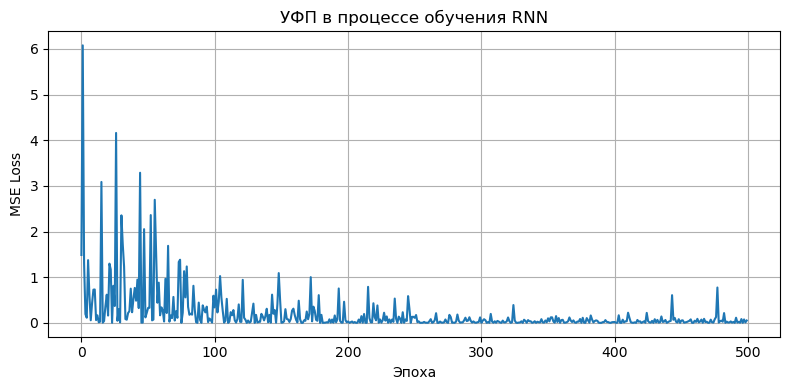

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Эпоха")
plt.ylabel("MSE Loss")
plt.title("УФП в процессе обучения RNN")
plt.grid(True)
plt.tight_layout()
plt.show()